<a href="https://colab.research.google.com/github/OMDATTA/KUNAL-DATTA/blob/main/student_performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction Using Machine Learning

## Objective

The objective of this project is to predict a student's final academic grade
using student academic and behavioral information.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Machine Learning

### Machine Learning Models

- Linear Regression
- Random Forest Regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"

!wget -q $url -O student.zip
!unzip -o student.zip

Archive:  student.zip
  inflating: student-mat.csv         
  inflating: student-por.csv         
  inflating: student-merge.R         
  inflating: student.txt             


In [5]:
df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

df.describe()

Dataset Shape:
(395, 33)

Dataset Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 n

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("Number of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates removed.")
print("New dataset shape:", df.shape)

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
Number of duplicate rows: 0
Duplicates removed.
New dataset shape: (395, 33)


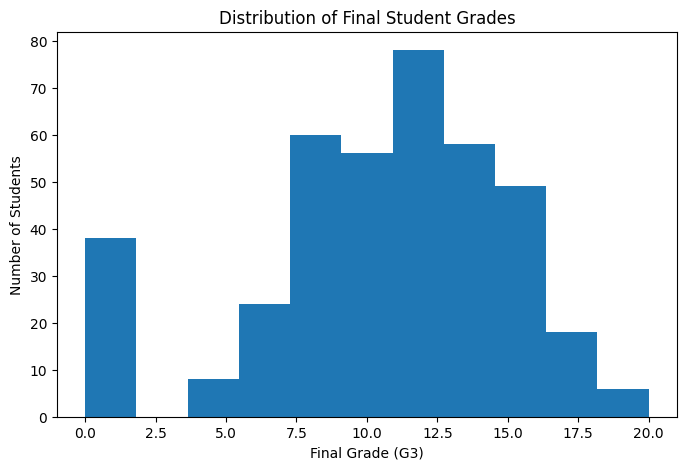

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["G3"], bins=11)

plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Student Grades")

plt.show()

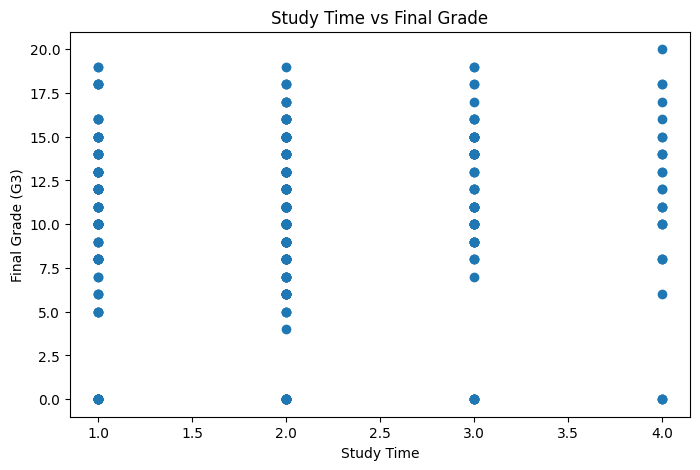

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(df["studytime"], df["G3"])

plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs Final Grade")

plt.show()

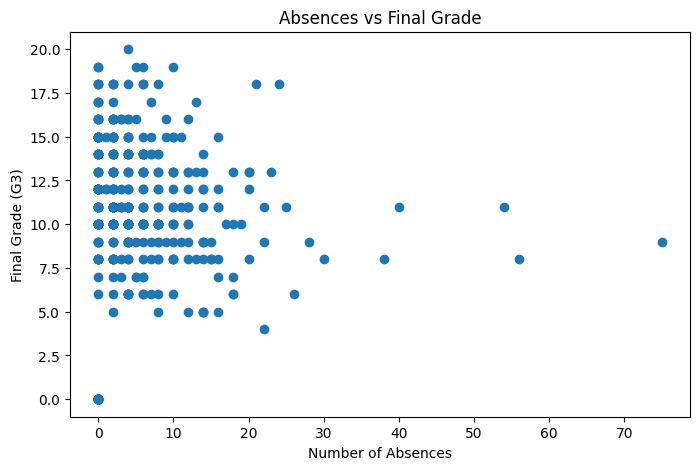

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(df["absences"], df["G3"])

plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.title("Absences vs Final Grade")

plt.show()

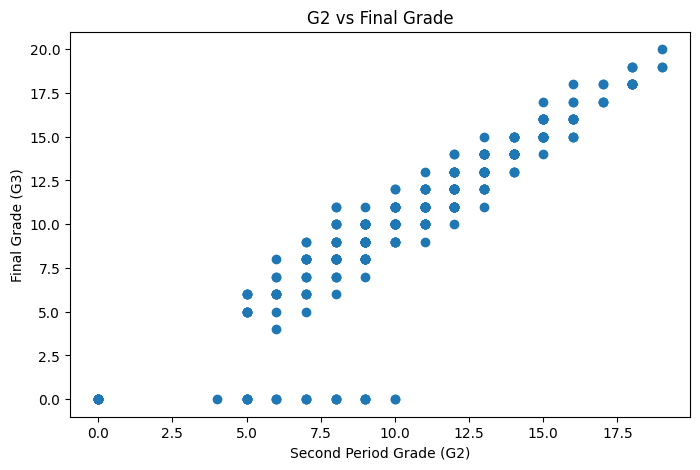

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(df["G2"], df["G3"])

plt.xlabel("Second Period Grade (G2)")
plt.ylabel("Final Grade (G3)")
plt.title("G2 vs Final Grade")

plt.show()

In [38]:
# Select features
features = [
    "age",
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2"
]

# Create feature dataset
X = df[features].copy()

# Target variable
y = df["G3"]

print("Selected Features:")
print(X.columns.tolist())

print("\nFirst 5 rows of processed data:")
print(X.head())

print("\nTarget Variable:")
print("G3 - Final Grade")

Selected Features:
['age', 'studytime', 'failures', 'absences', 'G1', 'G2']

First 5 rows of processed data:
   age  studytime  failures  absences  G1  G2
0   18          2         0         6   5   6
1   17          2         0         4   5   5
2   15          2         3        10   7   8
3   15          3         0         2  15  14
4   16          2         0         4   6  10

Target Variable:
G3 - Final Grade


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 316
Testing samples: 79


In [15]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [16]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²  :", round(linear_r2, 3))

Linear Regression Performance
--------------------------------
MAE : 1.334
RMSE: 2.112
R²  : 0.782


In [17]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [18]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")
print("---------------------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

Random Forest Performance
---------------------------
MAE : 1.038
RMSE: 1.732
R²  : 0.854


In [19]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.334018,2.112361,0.782392
1,Random Forest,1.037802,1.731820,0.853734


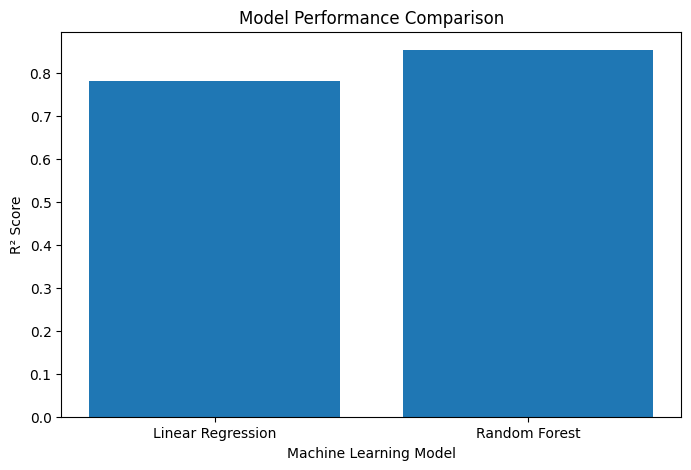

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.show()

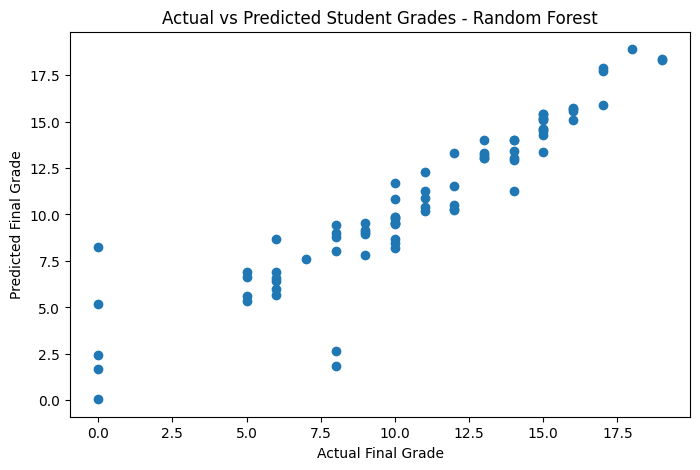

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")

plt.title(
    "Actual vs Predicted Student Grades - Random Forest"
)

plt.show()

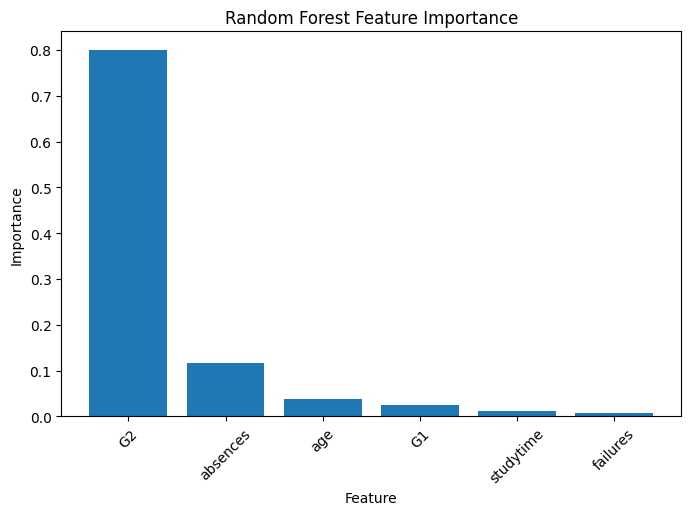

In [22]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()

In [40]:
new_student = pd.DataFrame({
    "age": [17],
    "studytime": [3],
    "failures": [0],
    "absences": [5],
    "G1": [11],
    "G2": [11]
})

# Make prediction
predicted_grade = rf_model.predict(new_student)[0]

print("Predicted Final Grade:", round(predicted_grade, 2))

Predicted Final Grade: 10.79


In [39]:
grade = float(predicted_grade)

if grade >= 15:
    category = "High Performance"
elif grade >= 10:
    category = "Average Performance"
else:
    category = "Low Performance"

print("Predicted Grade:", round(grade, 2))
print("Performance Category:", category)

Predicted Grade: 10.79
Performance Category: Average Performance


# Conclusion

In this project, machine learning techniques were used to predict student
final academic performance.

The dataset was first inspected and cleaned, followed by exploratory data
analysis to understand relationships between student characteristics and
final grades.

Two regression models were trained:

1. Linear Regression
2. Random Forest Regression

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the better evaluation performance can be selected for making
future predictions.

The project demonstrates the complete machine learning workflow from
data preprocessing and visualization to model training, evaluation and
prediction.